In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.size

32970000

In [10]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
X = df.drop(columns=['label'])
y = df['label']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
X_train.shape

(33600, 784)

In [14]:
X_test.shape

(8400, 784)

In [15]:
y_train.shape

(33600,)

In [16]:
y_test.shape

(8400,)

In [17]:
X_train_arr = X_train.values
X_test_arr = X_test.values

In [18]:
y_train_arr = y_train.values
y_test_arr=y_test.values

In [19]:
y_train_arr[1]

np.int64(3)

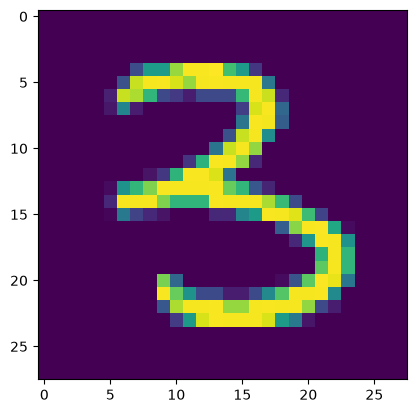

In [20]:
import matplotlib.pyplot as plt
plt.imshow(X_train_arr[1].reshape(28,28))
plt.show()

In [21]:
X_train_scaled = X_train_arr/255
X_test_scaled = X_test_arr/255

In [22]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Dropout

In [23]:
model = Sequential()
model.add(Dense(128,input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax')) 

C:\Users\poona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [25]:
# Base model training
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)
history = model.fit(
    X_train_scaled,  
    y_train_arr,  
    epochs=25,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=True,  
)

Epoch 1/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8553 - loss: 0.4759 - val_accuracy: 0.9333 - val_loss: 0.2324
Epoch 2/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9174 - loss: 0.2729 - val_accuracy: 0.9426 - val_loss: 0.1969
Epoch 3/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9290 - loss: 0.2326 - val_accuracy: 0.9503 - val_loss: 0.1715
Epoch 4/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9369 - loss: 0.2075 - val_accuracy: 0.9548 - val_loss: 0.1534
Epoch 5/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9407 - loss: 0.1901 - val_accuracy: 0.9573 - val_loss: 0.1513
Epoch 6/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9444 - loss: 0.1759 - val_accuracy: 0.9557 - val_loss: 0.1533
Epoch 7/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9493 - loss: 0.1652 - val_accuracy: 0.9563 - val_loss: 0.1588
Epoch 8/25
840/840 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9490 - loss: 0.1625 - val_accuracy: 0.

In [26]:
y_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
# Model testing
print("Predicted Labels (First 10):", y_pred[:25])
print("Actual Labels (First 10):   ", y_test_arr[:25])

Predicted Labels (First 10): [1 8 6 8 5 7 6 7 7 7 8 8 4 4 2 6 7 1 1 4 6 8 7 9 8]
Actual Labels (First 10):    [1 8 6 9 5 7 6 7 7 7 8 8 4 4 2 6 7 1 1 4 6 8 7 9 8]


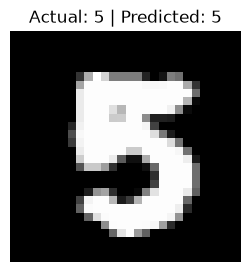

In [28]:
plt.figure(figsize=(3, 3))
plt.imshow(X_test_scaled[7489].reshape(28, 28), cmap='gray')

plt.title(f'Actual: {y_test_arr[7489]} | Predicted: {y_pred[7489]}')
plt.axis('off') 
plt.show()

In [29]:
# Model performance 
from sklearn.metrics import accuracy_score
accuracy_score(y_test_arr,y_pred)

0.9615476190476191

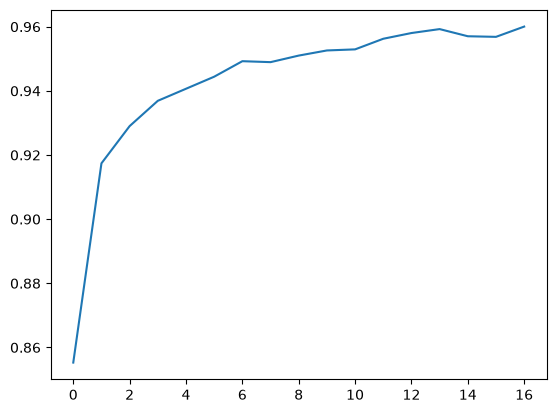

In [30]:
plt.plot(history.history['accuracy'])

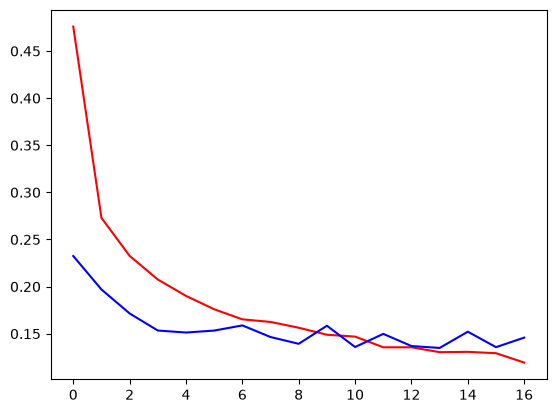

In [31]:
plt.plot(history.history['loss'],color='red')
plt.plot(history.history['val_loss'],color='blue')

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


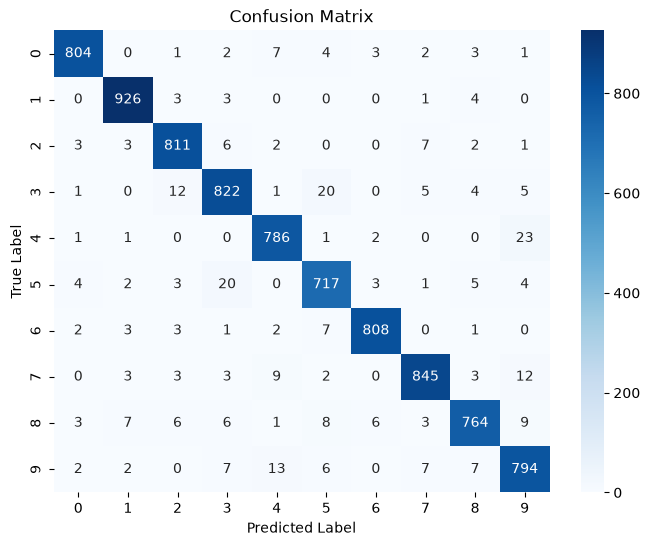

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       827
           1       0.98      0.99      0.98       937
           2       0.96      0.97      0.97       835
           3       0.94      0.94      0.94       870
           4       0.96      0.97      0.96       814
           5       0.94      0.94      0.94       759
           6       0.98      0.98      0.98       827
           7       0.97      0.96      0.97       880
           8       0.96      0.94      0.95       813
           9       0.94      0.95      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



In [32]:
# confusion metrix and precession score for based model
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
  y_true = np.argmax(y_test, axis=1)
else:
  y_true = y_test

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred))

In [33]:
# Hyperparameter tunning for improvement 
import os
import shutil
import keras_tuner as kt

from tensorflow.keras.optimizers import Adam
if os.path.exists('tuning_dir'):
    shutil.rmtree('tuning_dir')

def build_model(hp):
    model = Sequential()
    hp_units = hp.Int(
        'units',
        min_value=64,
        max_value=256,
        step=64
    )
    model.add(
        Dense(
            units=hp_units,
            activation='relu',
            input_shape=(784,)
        )
    )
    hp_dropout = hp.Float(
        'dropout',
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )
    model.add(Dropout(rate=hp_dropout))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    hp_lr = hp.Choice(
        'learning_rate',
        values=[1e-2, 1e-3, 1e-4]
    )
    model.compile(
        optimizer=Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='tuning_dir',
    project_name='mnist_mlp_tuning'
)
X_train_flat = X_train_scaled.reshape(-1, 784)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
tuner.search(
    X_train_flat,
    y_train_arr,
    epochs=25,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping]
)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('--- BEST HYPERPARAMETERS FOUND ---')
print(f"Optimal Units: {best_hps.get('units')}")
print(f"Optimal Dropout Rate: {best_hps.get('dropout')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")

Trial 5 Complete [00h 00m 45s]
val_accuracy: 0.9717261791229248

Best val_accuracy So Far: 0.9751487970352173
Total elapsed time: 00h 06m 45s
--- BEST HYPERPARAMETERS FOUND ---
Optimal Units: 256
Optimal Dropout Rate: 0.2
Optimal Learning Rate: 0.001


In [34]:
# 1. Best Hyperparameters se Model Re-build Karein
final_model = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.2),  # Tuned Dropout Rate
    Dense(64, activation='relu'),
    Dense(10, activation='softmax'),
])

final_model.compile(
    optimizer=Adam(learning_rate=0.001),  # Tuned Learning Rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# 2. EarlyStopping setup
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# 3. Full Scale Training
hist = final_model.fit(
    X_train_scaled.reshape(-1, 784),
    y_train_arr,
    epochs=30,  # Epochs badha diye hain
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8979 - loss: 0.3461 - val_accuracy: 0.9476 - val_loss: 0.1716
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9549 - loss: 0.1490 - val_accuracy: 0.9635 - val_loss: 0.1288
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9670 - loss: 0.1046 - val_accuracy: 0.9610 - val_loss: 0.1217
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9739 - loss: 0.0827 - val_accuracy: 0.9659 - val_loss: 0.1107
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9788 - loss: 0.0664 - val_accuracy: 0.9716 - val_loss: 0.0987
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9811 - loss: 0.0567 - val_accuracy: 0.9676 - val_loss: 0.1189
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9844 - loss: 0.0472 - val_accuracy: 0.9701 - val_loss: 0.1080
Epoch 8/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9874 - loss: 0.0390 - val_accuracy: 0.

In [35]:
y_final_prob = final_model.predict(X_test_scaled)
y_pred_labels = np.argmax(y_final_prob,axis=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [36]:
print("Predicted Labels (First 10):", y_pred_labels[:25])
print("Actual Labels (First 10):   ", y_test_arr[:25])

Predicted Labels (First 10): [1 8 6 9 5 7 6 7 7 7 8 8 4 4 2 6 7 1 1 4 6 8 7 9 8]
Actual Labels (First 10):    [1 8 6 9 5 7 6 7 7 7 8 8 4 4 2 6 7 1 1 4 6 8 7 9 8]


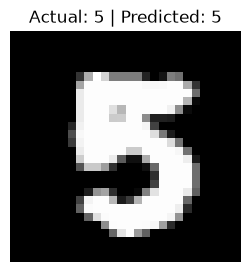

In [37]:
plt.figure(figsize=(3, 3))
plt.imshow(X_test_scaled[7489].reshape(28, 28), cmap='gray')

plt.title(f'Actual: {y_test_arr[7489]} | Predicted: {y_pred_labels[7489]}')
plt.axis('off') 
plt.show()

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test_arr,y_pred_labels)

0.9711904761904762

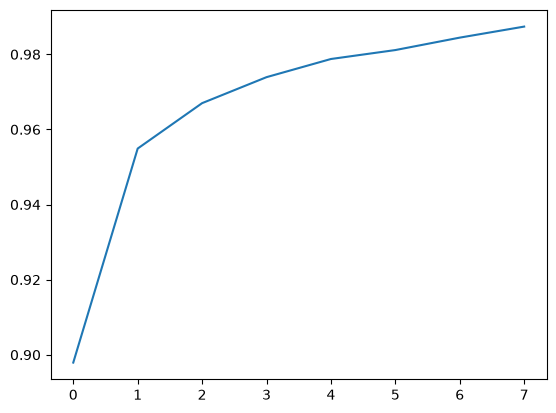

In [39]:
plt.plot(hist.history['accuracy'])

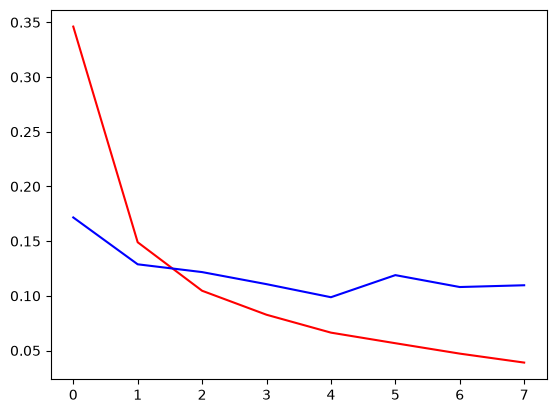

In [40]:
plt.plot(hist.history['loss'],color='red')
plt.plot(hist.history['val_loss'],color='blue')

In [41]:
# Model evalution
X_test_flat = X_test_scaled.reshape(-1, 784)

test_loss, test_acc = final_model.evaluate(
    X_test_flat,
    y_test_arr
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9712 - loss: 0.0974
Final Test Loss: 0.0974
Final Test Accuracy: 97.12%


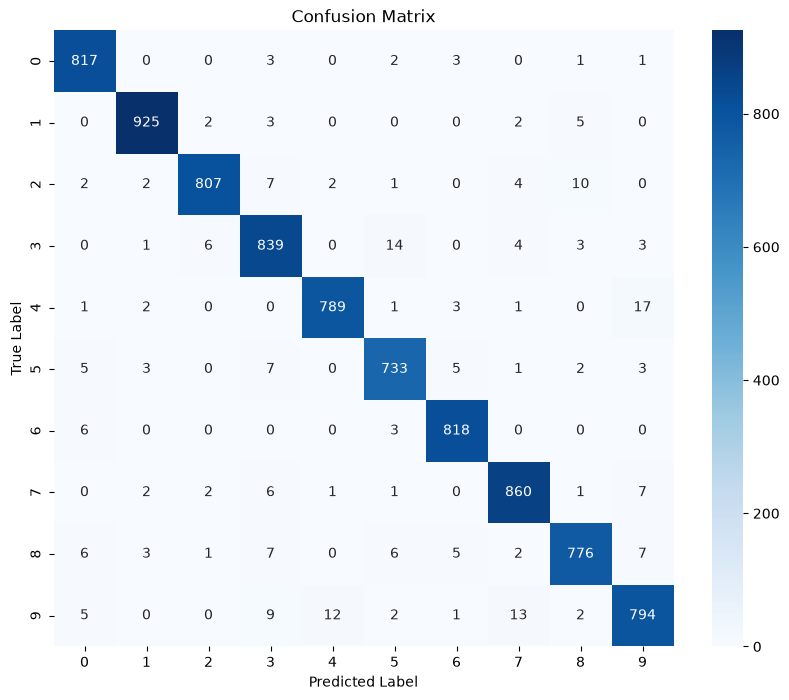

In [42]:
cm = confusion_matrix(y_test_arr, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test_arr, y_pred_labels))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       827
           1       0.99      0.99      0.99       937
           2       0.99      0.97      0.98       835
           3       0.95      0.96      0.96       870
           4       0.98      0.97      0.98       814
           5       0.96      0.97      0.96       759
           6       0.98      0.99      0.98       827
           7       0.97      0.98      0.97       880
           8       0.97      0.95      0.96       813
           9       0.95      0.95      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



In [44]:
baseline_loss, baseline_acc = model.evaluate(
    X_test_scaled,
    y_test_arr
)
print(f"Baseline Test Accuracy: {baseline_acc * 100:.2f}%")

final_loss, final_acc = final_model.evaluate(
    X_test_flat,
    y_test_arr
)
print(f"Final Test Accuracy: {final_acc * 100:.2f}%")

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9615 - loss: 0.1352
Baseline Test Accuracy: 96.15%
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9712 - loss: 0.0974
Final Test Accuracy: 97.12%


In [45]:
print("========== MODEL COMPARISON ==========")

print(f"Baseline Test Accuracy : {baseline_acc * 100:.2f}%")
print(f"Final Test Accuracy    : {final_acc * 100:.2f}%")
improvement = (final_acc - baseline_acc) * 100
print(f"Improvement             : {improvement:.2f} percentage points")

========== MODEL COMPARISON ==========
Baseline Test Accuracy : 96.15%
Final Test Accuracy    : 97.12%
Improvement             : 0.96 percentage points


In [46]:
final_model.save("mnist_mlp.keras")

In [47]:
from tensorflow.keras.models import load_model
model = load_model("mnist_mlp.keras")

In [49]:
prediction = model.predict(X_test_flat)
y_pred = np.argmax(prediction, axis=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [53]:
print(y_test_arr)
print(y_pred)

[1 8 6 ... 7 7 1]
[1 8 6 ... 7 7 1]
